<a href="https://colab.research.google.com/github/Flip-data96/Python-para-analise-de-dados/blob/main/Detec%C3%A7%C3%A3o_de_anomalias_em_transa%C3%A7%C3%B5es_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Detecção de Fraudes com Machine Learning

## 📌 Problema
Fraudes em transações financeiras são eventos raros, representando uma pequena fração do dataset.  
Isso gera um problema de **classificação desbalanceada**, onde modelos podem ignorar a classe minoritária.

## 🎯 Objetivo
Construir modelos capazes de detectar fraudes com alta sensibilidade (**recall**), mantendo bom equilíbrio com precisão.

## 🧠 Técnicas utilizadas
- Regressão Logística
- Random Forest
- XGBoost
- Balanceamento de dados (SMOTE)
- Ajuste de threshold
- Interpretabilidade com SHAP

In [3]:
## Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import shap

## 📊 Carregamento dos Dados
Dataset de transações financeiras para detecção de fraudes.

In [4]:

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 🔍 Análise Exploratória

Verificando desbalanceamento da variável alvo.

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


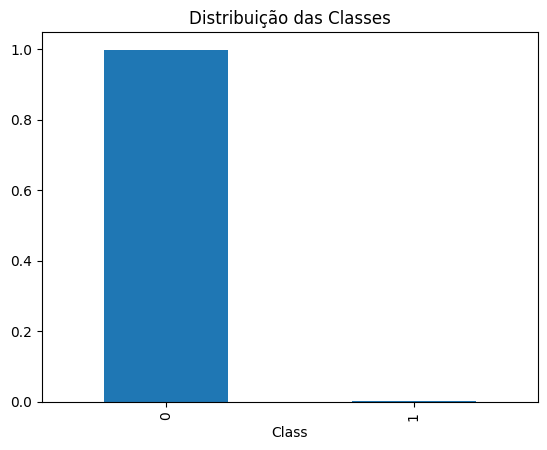

In [5]:
class_dist = df["Class"].value_counts(normalize=True)
print(class_dist)

class_dist.plot(kind="bar", title="Distribuição das Classes")
plt.show()

## ⚙️ Feature Engineering

Transformações para melhorar a performance do modelo.

In [6]:
df["Amount_log"] = np.log1p(df["Amount"])

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

## 🔀 Divisão dos Dados

Utilizamos stratify para manter a proporção de fraudes.

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

## 🤖 Modelo Base: Regressão Logística

In [8]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



## 📈 Avaliação com ROC Curve

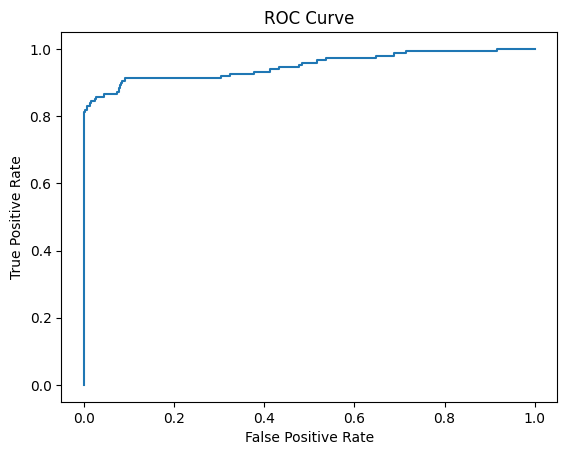

AUC: 0.9488893078552496


In [9]:
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

## 📉 Precision-Recall Curve

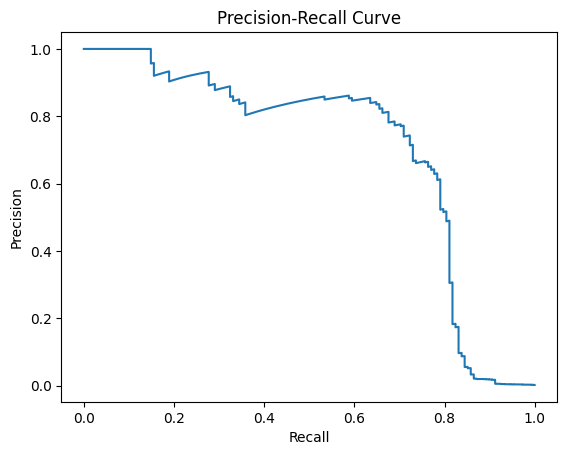

In [10]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## ⚖️ Ajuste de Threshold

Reduzimos o threshold para aumentar o recall.

In [11]:
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.68      0.73       148

    accuracy                           1.00     85443
   macro avg       0.90      0.84      0.86     85443
weighted avg       1.00      1.00      1.00     85443



## 🔄 Balanceamento com SMOTE

In [12]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

## 🌲 Modelo: Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



## 🚀 Modelo: XGBoost

In [14]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:46:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



## 🔍 Interpretabilidade com SHAP

Entendendo quais variáveis mais influenciam o modelo.

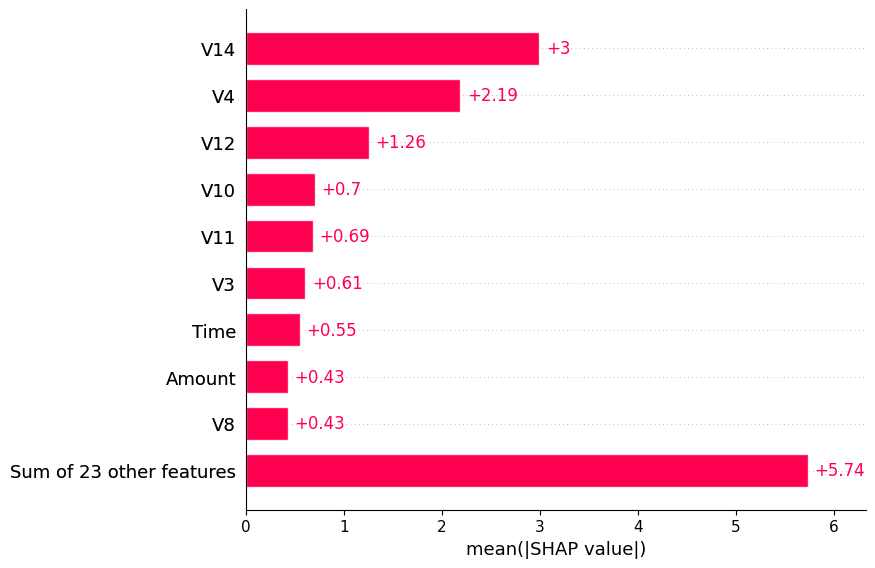

In [15]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

## 🧠 Conclusão

- Modelos tradicionais podem falhar em dados desbalanceados
- Ajuste de threshold melhora detecção de fraudes
- Técnicas como SMOTE ajudam no aprendizado
- XGBoost apresentou melhor desempenho geral
- SHAP permite interpretar decisões do modelo

📌 Projetos de detecção de fraude devem priorizar **recall**, não apenas accuracy.